# 📈 Pembangkitan Data Skenario & Validasi

Notebook ini memvalidasi keunikan data deret waktu harian untuk wilayah domestik AS (`Market = USCA`), serta memformulasikan dataset skenario sintetis (data dengan modifikasi noise acak terkontrol) untuk analisis keandalan model tanpa merusak keruntutan deret waktu (tiada duplikasi tanggal).

## 1. Memuat Dataset Hasil Preprocessing

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
df_processed = pd.read_csv('data/processed/cold_chain_data.csv')
df_processed['order date (DateOrders)'] = pd.to_datetime(df_processed['order date (DateOrders)'])
print(f"Dataset processed termuat. Shape: {df_processed.shape}")

Dataset processed termuat. Shape: (25799, 22)


## 2. Agregasi Harian & Pengecekan Keunikan Tanggal

In [2]:
daily_df = df_processed.groupby(df_processed['order date (DateOrders)'].dt.date).agg({
    'Order Item Quantity': 'sum',
    'ambient_temp': 'mean'
}).reset_index()
daily_df.rename(columns={'order date (DateOrders)': 'date', 'Order Item Quantity': 'demand'}, inplace=True)
daily_df['date'] = pd.to_datetime(daily_df['date'])
daily_df = daily_df.sort_values('date').set_index('date').resample('D').agg({
    'demand': 'sum',
    'ambient_temp': 'mean'
})
daily_df['ambient_temp'] = daily_df['ambient_temp'].ffill().bfill()

print(f"Data harian terbentuk. Jumlah baris: {len(daily_df)}")
print(f"Pengecekan keunikan indeks tanggal (Harus True): {daily_df.index.is_unique}")

Data harian terbentuk. Jumlah baris: 291
Pengecekan keunikan indeks tanggal (Harus True): True


## 3. Pembangkitan Data Skenario Sintetis yang Valid

Untuk membuat data pengujian keandalan tanpa melakukan kloning baris mentah yang merusak nilai sum resampling, kami menambahkan derau Gaussian kecil (±5%) ke permintaan asli dan menyimpan dataset skenario unik ini.

In [3]:
np.random.seed(42)
noise = np.random.normal(0, 0.05, len(daily_df))
synthetic_demand = daily_df['demand'] * (1.0 + noise)
synthetic_demand = np.clip(synthetic_demand, 0.0, None)

df_synthetic = daily_df.copy()
df_synthetic['demand'] = synthetic_demand

out_dir = './data/processed'
os.makedirs(out_dir, exist_ok=True)
df_synthetic.to_csv(os.path.join(out_dir, 'synthetic_cold_chain_data.csv'))
print(f"Dataset skenario sintetis berhasil disimpan ke data/processed/synthetic_cold_chain_data.csv!")
print(df_synthetic.head())

Dataset skenario sintetis berhasil disimpan ke data/processed/synthetic_cold_chain_data.csv!
                demand  ambient_temp
date                                
2016-04-01   60.465307     22.260921
2016-04-02  350.559635     22.638857
2016-04-03  348.945936     22.943190
2016-04-04  318.540842     23.070095
2016-04-05  409.153025     23.188091


## 4. Visualisasi Perbandingan Data Asli vs Skenario Sintetis

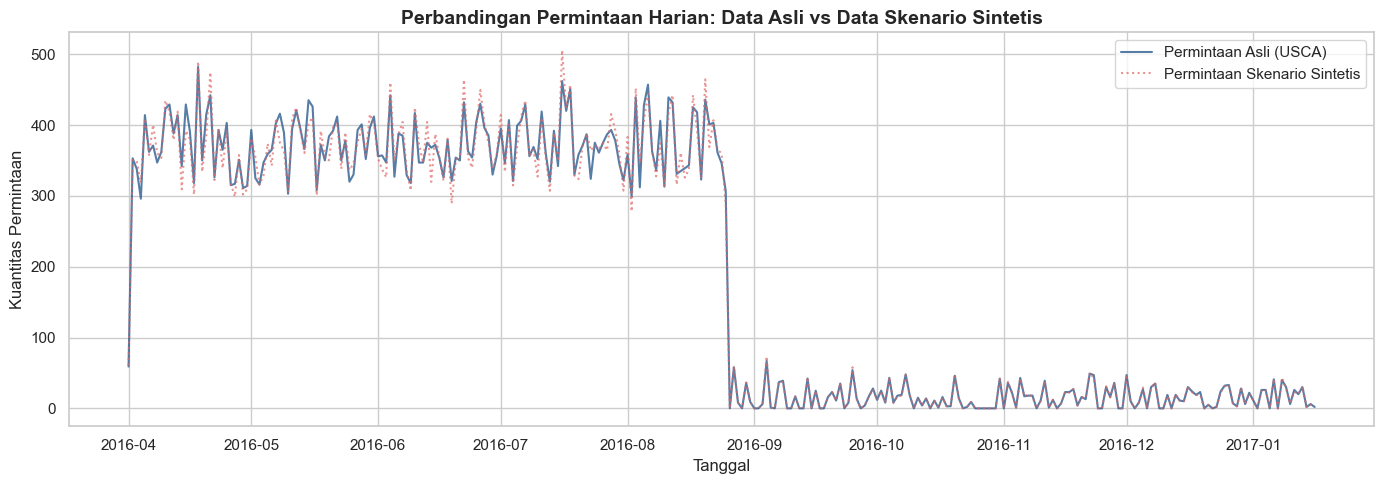

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(daily_df.index, daily_df['demand'], label='Permintaan Asli (USCA)', color='#2b5c8f', alpha=0.8)
plt.plot(df_synthetic.index, df_synthetic['demand'], label='Permintaan Skenario Sintetis', color='#e06666', alpha=0.7, linestyle=':')
plt.title('Perbandingan Permintaan Harian: Data Asli vs Data Skenario Sintetis', fontsize=14, fontweight='bold')
plt.ylabel('Kuantitas Permintaan')
plt.xlabel('Tanggal')
plt.legend()
plt.tight_layout()
plt.show()